In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")


In [2]:
 
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """ Get the weather at a location"""
    return f"it's sunny in {location}"

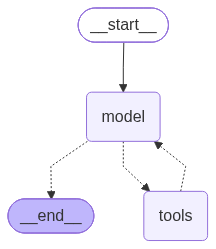

In [4]:
from langchain.agents import create_agent

agent = create_agent(
    model = "google_genai:gemini-3.5-flash",
    tools = [get_weather],
    system_prompt="You are a helpful assistant.",
)
agent

In [5]:
response = agent.invoke(
{"messages":
  [
    {
        "role":"user",
        "content":"What is the weather in bengaluru"
    }
  ]
}
)
response

{'messages': [HumanMessage(content='What is the weather in bengaluru', additional_kwargs={}, response_metadata={}, id='afca7121-71b7-4711-a26b-918c49b1080e'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "bengaluru"}'}, '__gemini_function_call_thought_signatures__': {'call_2133701': 'EvkCCvYCARFNMg9LRbCHIPMaQHxBgTbj5cQk4OIoCOmH7ILFMYHDLGg0ZQ+DQCwESgKn+rUtgOiTh4TMX5kEB9hdnMnHCjK4/dGY4rOuStWQaNxVSRdLtSkg+leg2/zBBIBtwbA1sCuZva3Rh3LxiJVgmsuxaJUvsZT5FCbUB925rR/DU38XI3pkErIkjdn/g6H1ollb/ovJn8aueW/7+ks/Vt9Pmi6U6nTR31cluflxU5lvo7qXm0oIpQvaclRF1/2PgeJhBQvAxwn5RoQnsXnPYJDBvivfYTRsTJSTC1bgJMF4C+JXfFg1jaszRTxGorsCH1TAd3Lr37kffzuRjlmjIcIamd2kVjsL9KHtO1WzDkx2JlzPHSQs5xbgjKfXhjmO++BHEw13Dxmr7ld4SFEiqjqHUjkywLcyP/KJhFqWDgv+AD/Aa8O3UlIsAQRfJ0HkJoBxGl+uaGYC4Xuii9dkvG6/WkD4Myz9uNgJVBWhBYmUcKUODKGdadA='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, i

In [8]:
response["messages"][-1].text

"It's sunny in Bengaluru."